In [1]:
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, ACCEPTANCE_COEFFS_PATH, C9, DEFAULT_STRIDE, DEFAULT_PRE_N, DEFAULT_PRERUNS, REAL_DATA
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.managers.imperfections_diagnostics import ImperfectionsDiagnostics
from sbi_particle_physics.managers.model_diagnostics import ModelDiagnostics
from sbi_particle_physics.managers.real_data import RealData
import torch

In [2]:
device = "cpu" # this small test works on cpu
n_points = 100
model = Model(device, n_points=n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=DEFAULT_STRIDE, pre_N=DEFAULT_PRE_N, preruns=DEFAULT_PRERUNS, use_imperfections=True, acceptance_coeffs_path=ACCEPTANCE_COEFFS_PATH)
model.set_normalizer(model.to_tensor([0,0,0,0,0,0]), model.to_tensor([1,1,1,1,1,1]))

In [3]:
datasets = ImperfectionsDiagnostics.get_datasets(model, n_points=n_points)

Simulating samples:   0%|          | 0/1 [00:00<?, ?it/s]

/home/hep/nrc25/miniconda3/envs/mlhep/lib/python3.12/site-packages/eos/signal_pdf.py:71: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  log_proposal = pypmc.density.gauss.LocalGauss(sigma)


Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

max eps 0.0793599784374237, mean eps 0.056031905114650726, median eps 0.06169833615422249, min eps 0.006117336917668581
eps < 0: 0.0%, eps > 1: 0.0%
max eps 0.0793599784374237, mean eps 0.056031905114650726, median eps 0.06169833615422249, min eps 0.006117336917668581
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 2 out of 100 events (2.0%)


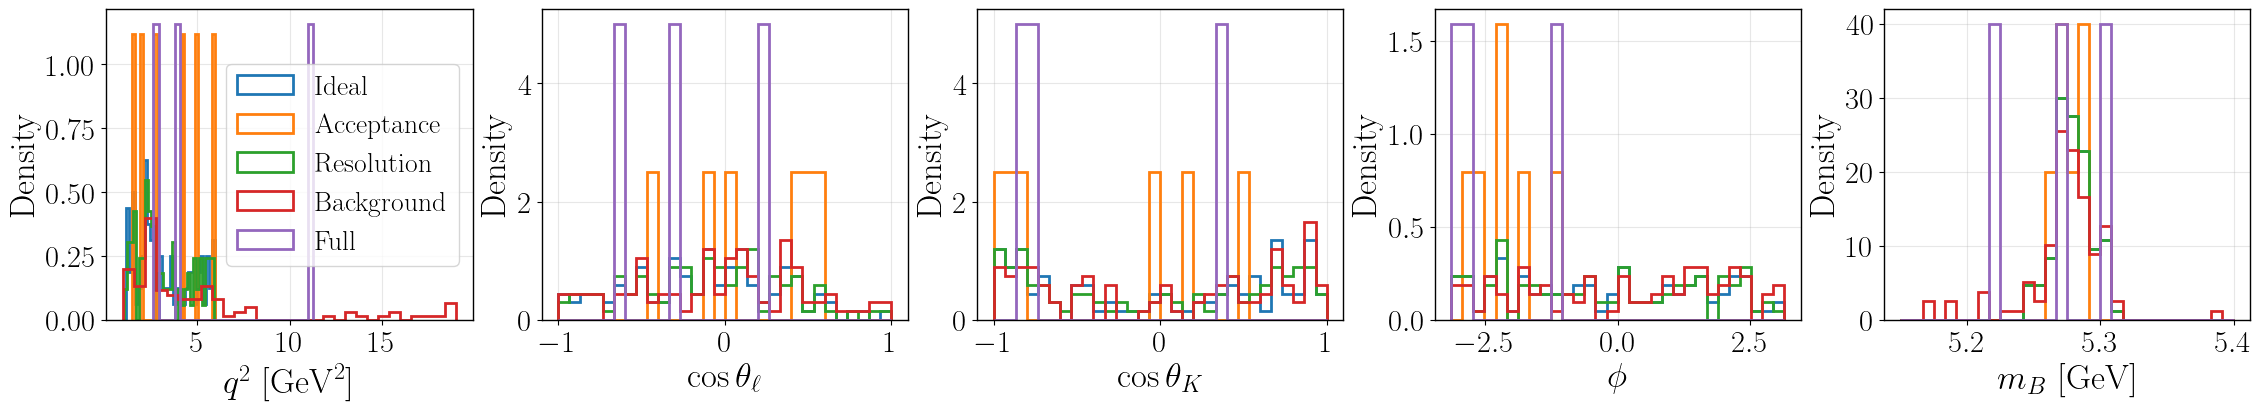

In [4]:
ImperfectionsDiagnostics.compare_datasets(datasets)

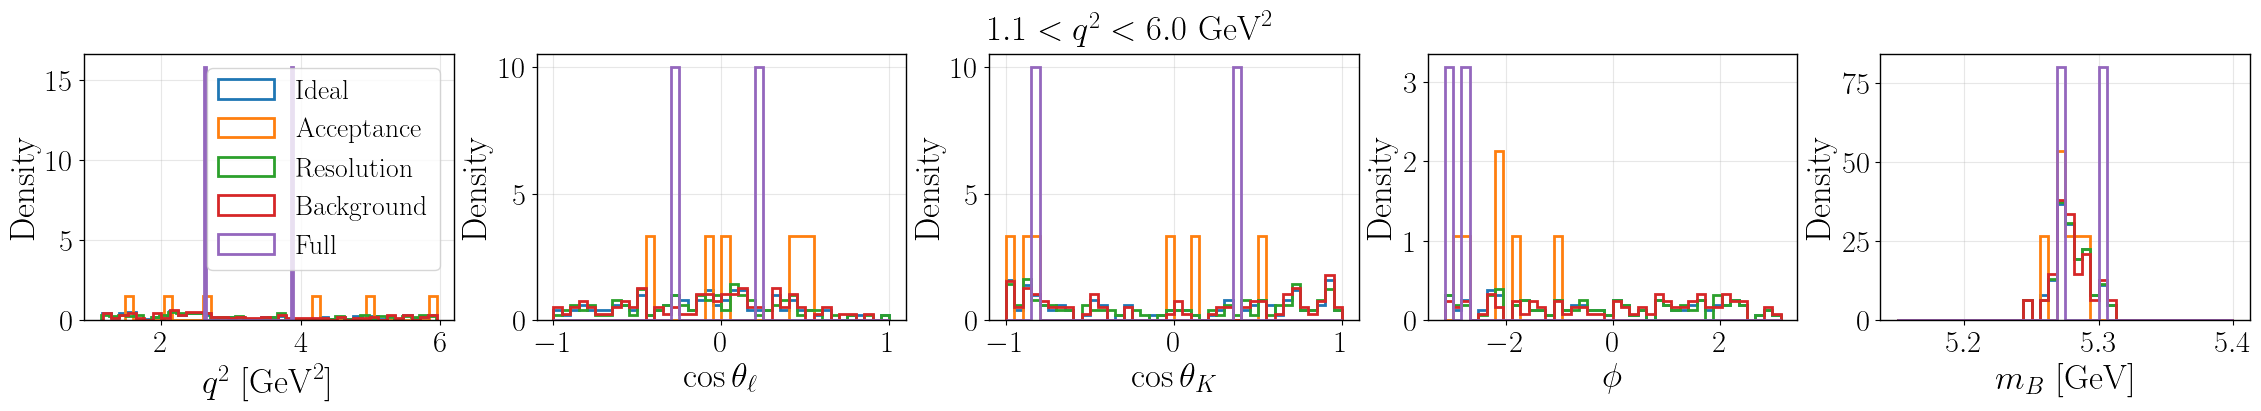

In [5]:
ImperfectionsDiagnostics.compare_datasets(datasets, q2_bin=(1.1, 6.0), bins=40)

In [6]:
real_raw_data = RealData.load_n_points(REAL_DATA, n_points=n_points, device=device)

Loading LHCb data (partial):   0%|          | 0/40 [00:00<?, ?it/s]

In [7]:
print(real_raw_data[:,:].mean(dim=0))
print(real_raw_data[:,-1].mean())

tensor([ 3.4482,  0.0685, -0.1043, -0.0056,  5.2924])
tensor(5.2924)


In [8]:
x_real = real_raw_data
x_acc = datasets["Acceptance"] # .squeeze(0)
x_sim = datasets["Ideal"] # "Full"

In [ ]:
x_sim_long, parameters_sim_long = model.simulate_raw_data(n_samples=10, n_points=n_points)

Simulating samples:   0%|          | 0/2 [00:00<?, ?it/s]

Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

max eps 0.17179961502552032, mean eps 0.056655146181583405, median eps 0.061977241188287735, min eps 0.005013591609895229
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 33 out of 600 events (5.5%)


Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

...

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

max eps 0.11413370817899704, mean eps 0.05608484894037247, median eps 0.061061061918735504, min eps 0.00242903595790267
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 41 out of 600 events (6.8%)


Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

max eps 0.16658088564872742, mean eps 0.05563724413514137, median eps 0.060811132192611694, min eps 0.0030562342144548893
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 29 out of 600 events (4.8%)


In [10]:
print(x_real[4].mean())

tensor(2.0742)


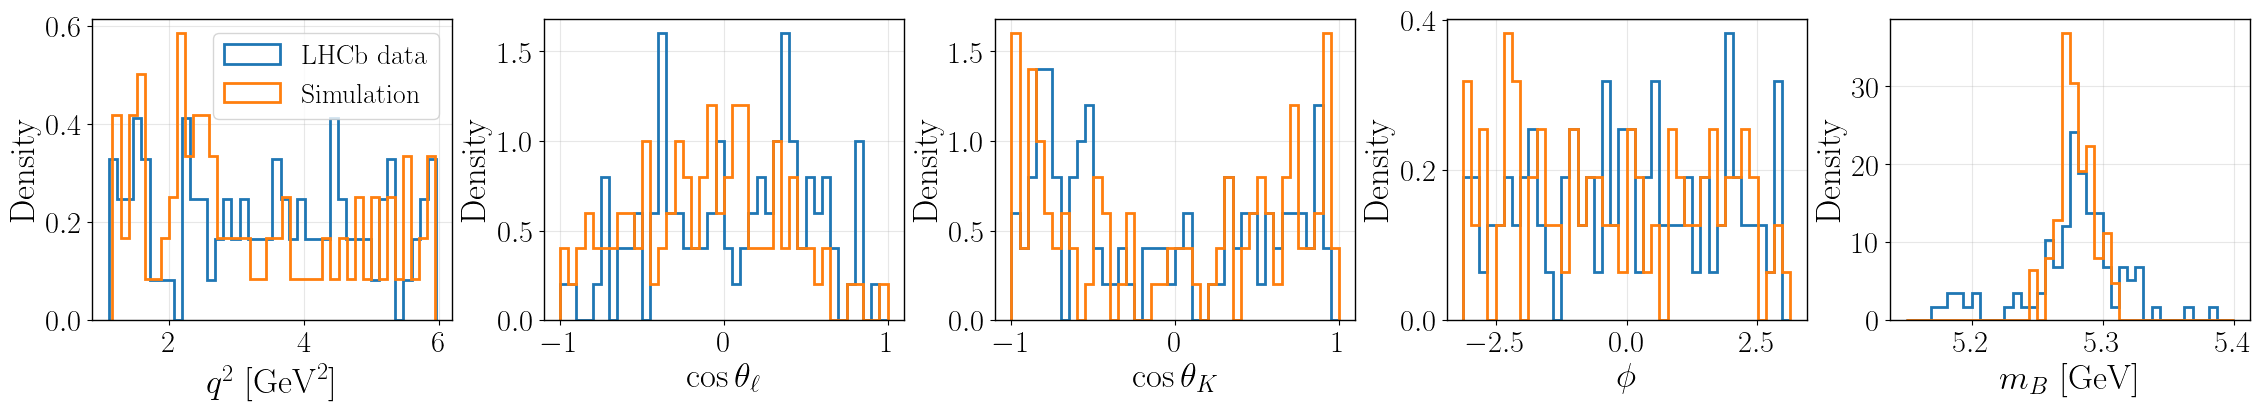

In [11]:
ImperfectionsDiagnostics.compare_real_vs_simulated(x_real, x_sim, bins=40)

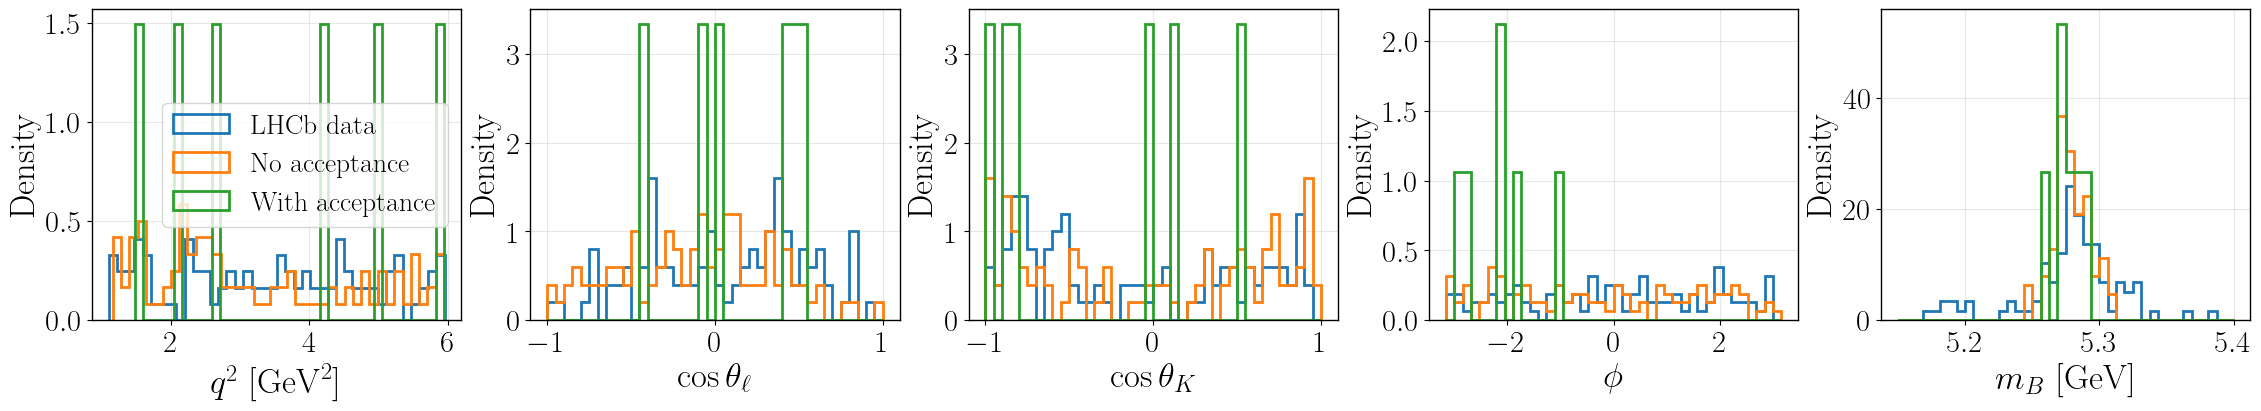

In [12]:
ImperfectionsDiagnostics.compare_real_vs_simulated_vs_accepted(x_real, x_sim, x_acc, bins=40)

In [13]:
ImperfectionsDiagnostics.chi2_test(x_sim, x_real, bins=40)

$q^2\ [\mathrm{GeV}^2]$ : chi2/ndof = 29.24/39, p = 0.872
$\cos\theta_\ell$ : chi2/ndof = 41.88/39, p = 0.347
$\cos\theta_K$ : chi2/ndof = 38.74/39, p = 0.482
$\phi$ : chi2/ndof = 32.65/39, p = 0.753
$m_B\ [\mathrm{GeV}]$ : chi2/ndof = 46.26/39, p = 0.197


In [14]:
ModelDiagnostics.misspecification_test(x_sim_long, x_o=x_real) # <----

/home/hep/nrc25/miniconda3/envs/mlhep/lib/python3.12/site-packages/sbi/utils/sbiutils.py:280: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  t_std = torch.std(batch_t[is_valid_t], dim=0)


AssertionError: NaN/Inf present in loss.

MMD p-value: 1.0


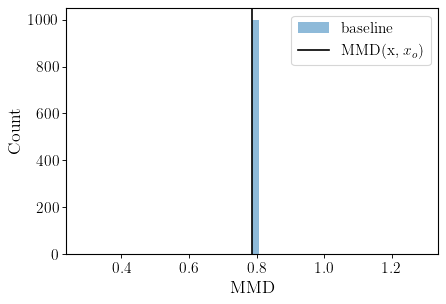

In [15]:
ModelDiagnostics.misspecification_test_mmd(x_sim_long, x_o=x_real)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)

In [ ]:
x_obs, parameter_obs = model.simulate_raw_data(n_samples=1, n_points=n_points)
x_obs = x_obs.squeeze(0)

Simulating samples:   0%|          | 0/1 [00:00<?, ?it/s]

Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
ImperfectionsDiagnostics.chi2_test(x_sim, x_obs, bins=40)

In [ ]:
ModelDiagnostics.misspecification_test(x_sim_long, x_o=x_obs) # <----

In [ ]:
ModelDiagnostics.misspecification_test_mmd(x_sim_long, x_o=x_obs)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)